In [1]:
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Tensor is a generalized multi dimensional array
# Tensor if the fundamental data structure in PyTorch
# Input output, weight and gradient are all tensors

# Dimensions
d0 = torch.tensor(3.14)
print(d0, d0.ndim)  # 0
d1 = torch.tensor([3.14, 2.71, 1.62])
print(d1, d1.ndim)  # 1
d2 = torch.tensor([[3.14, 2.71, 1.62], [1.41, 1.73, 2.23]])
print(d2, d2.ndim)  # 2
d3 = torch.tensor([[[3.14, 2.71, 1.62], [1.41, 1.73, 2.23]], [[0.11, 0.22, 0.33], [0.44, 0.55, 0.66]]])
print(d3, d3.ndim)  # 3

In [ ]:
# Creating tensors
a = torch.tensor([1, 2, 3], dtype=torch.float32)
print(a, a.dtype)  # 1
b = torch.zeros((2, 3), dtype=torch.float32)
print(b, b.dtype)  # 2
c = torch.rand((2, 3), dtype=torch.float32)
print(c, c.dtype)  # 3
print(c.shape, c.device)

In [ ]:
# Operations on a tensor
a = torch.tensor([[1, 2, 3],[4,5,6]], dtype=torch.float32)
print(a.ndim, a.shape)  # 2, (2,3)
print(a*a, a+a)
print(a@a.T)

In [ ]:
# Numpy arrays and Pytorch tensors are interchangeable
n = np.array([[1, 2, 3],[4,5,6]])
t = torch.from_numpy(n)  # Convert numpy array to torch tensor
print(t, t.dtype)
n1 = t.numpy()  # Convert torch tensor to numpy array
print(n1, n1.dtype)
n1+=5
print(n1, n1.dtype)
print(t, t.dtype)  # The torch tensor is also updated


In [ ]:
## Computational graph
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
z = w * x + b #7
y = z ** 2 # 49
print(y)
y.backward()  # Compute gradients - Autograd
print(x.grad, w.grad, b.grad)  # 28.0, 14.0, 7.0

In [ ]:
w = torch.tensor(3.0, requires_grad=True)
for i in range(3):
    loss =  (w*2.0 - 4.0)**2
    loss.backward()
    print(w.grad)
    w.grad.zero_()  # Reset gradients to zero before next iteration


In [ ]:
## Factory functions to create tensors
a = torch.zeros((2, 3), dtype=torch.float32)
print(a, a.dtype)  # 2
b = torch.ones((2, 3), dtype=torch.float32)
print(b, b.dtype)  # 2
c = torch.eye(3)
print(c, c.dtype)  # 2
d = torch.randn((2, 3), dtype=torch.float32)
print(d, d.dtype)  # 2
e = torch.arange(0, 10, 2)
print(e, e.dtype)  # 2
x = torch.rand(2,3)
print(x, x.dtype)  # 2
y = torch.zeros_like(x)
print(y, y.dtype)  # 2
z = torch.ones_like(x)
print(z, z.dtype)  # 2
k = torch.empty((2, 3), dtype=torch.float32)
print(k, k.dtype)  # 2  
l = torch.empty_like(x)
print(l, l.dtype)  # 2
m = torch.rand_like(x)
print(m, m.dtype)  # 2


In [ ]:
## Indexing and slicing
a = torch.tensor([[1, 2, 3],[4,5,6]], dtype=torch.float32)
print(a.shape, a.ndim)  # 2, (2,3)
print(a[0:2, 0:2])  # 2x2
print(a[:,0])  # 2x1
a = a.reshape(3,2)  # Reshape to 3x2
print(a)  # 3x2
print(a.flatten())  # Flatten to 1D


In [ ]:
# Q1. Tensor creation: Create a 3x3 tensor filled with random values
# between 0 and 1, and normalize it so all entries sum to 1.
x = torch.rand(3, 3)
print("Original tensor:")
print(x)
print("Original sum:", x.sum().item())

x_norm = x / x.sum()
print("\nNormalized tensor:")
print(x_norm)
print("Normalized sum:", x_norm.sum().item())

In [ ]:
# Q2. Tensor reshaping: Reshape a 1D tensor of length 16 into a 4x4 matrix,
# then flatten it back.
x = torch.arange(16)
print("Original tensor:", x)
print("Original shape:", x.shape)

matrix = x.reshape(4, 4)
print("\n4x4 matrix:")
print(matrix)
print("Matrix shape:", matrix.shape)

flattened = matrix.flatten()
print("\nFlattened tensor:", flattened)
print("Flattened shape:", flattened.shape)

In [ ]:
# Q3. Matrix multiplication: Multiply two tensors with sizes 3x4 and 4x2,
# and verify the output shape.
x = torch.arange(12).view(3, 4)
y = torch.arange(8).view(4, 2)

result = x @ y
print("x shape:", x.shape)
print("y shape:", y.shape)
print("Result:")
print(result)
print("Result shape:", result.shape)

In [ ]:
# Q4. Autograd basics: Define a scalar function f(x) = x^2 + 3x.
# Compute the gradient at x = 2 using autograd.
x = torch.tensor(2.0, requires_grad=True)
f = x**2 + 3*x

f.backward()
print("x:", x.item())
print("f(x):", f.item())
print("df/dx at x=2:", x.grad.item())

In [ ]:
# Define a scalar function f(x) = (x^2 + 3x)^3 
# Compute the gradient at (x=2) using autograd.
x = torch.tensor(2.0, requires_grad=True)
f = (x**2 + 3*x)**3
# Compute the gradient using .backward()
f.backward()
print(x, x.grad.item())

In [62]:
# Define a scalar function f(x,y) = (x^2 *y + 3xy**2)**2 
# Compute the gradient at (x=2, y=3) using autograd.
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
f = (x**2*y+3*x*y**2)**2
# compute gradient using .backward()
f.backward()
print(x,x.grad.item())
print(y,y.grad.item())

tensor(2., requires_grad=True) 5148.0
tensor(3., requires_grad=True) 5280.0


In [ ]:
# Q5. Gradient tracking: Create a tensor with requires_grad=True,
# perform operations, and stop gradient tracking midway using torch.no_grad().
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x

with torch.no_grad():
    z = y * 5

print("y requires grad:", y.requires_grad)
print("z requires grad:", z.requires_grad)

y.backward()
print("Gradient of y with respect to x:", x.grad.item())

7.0


In [ ]:
# Q6. Custom loss function: Implement Mean Absolute Error (MAE) manually
# and compare with nn.L1Loss.
y_true = torch.tensor([[7.0], [9.0], [11.0], [13.0]])
y_pred = torch.tensor([[4.0], [6.0], [8.0], [10.0]])

manual_mae = torch.mean(torch.abs(y_true - y_pred))
l1_loss = nn.L1Loss()(y_pred, y_true)

print("Manual MAE:", manual_mae.item())
print("nn.L1Loss:", l1_loss.item())
print("Values match:", torch.isclose(manual_mae, l1_loss).item())

tensor([[1.],
        [2.],
        [3.],
        [4.]]) tensor([[ 7.],
        [ 9.],
        [11.],
        [13.]])
tensor(4.5000, grad_fn=<MeanBackward0>)
True


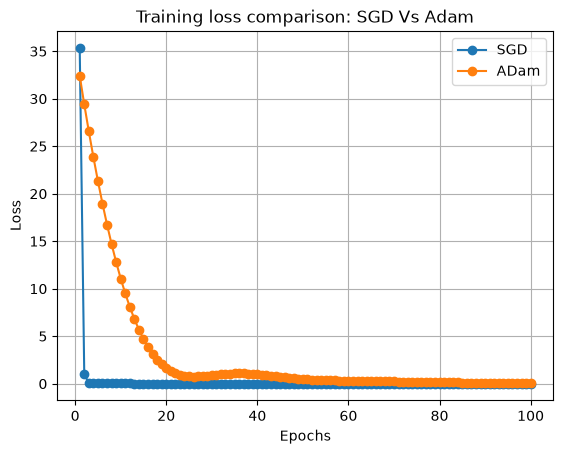

In [ ]:
# Q7. Linear regression: Build a simple linear regression model using nn.Linear
# and train it on synthetic data.
torch.manual_seed(42)

x_train = torch.linspace(0, 10, steps=100).unsqueeze(1)
y_train = 2 * x_train + 1 + 0.5 * torch.randn_like(x_train)

linear_model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.01)

# Q8. Training loop: forward pass, loss computation, backward pass,
# and optimizer step.
linear_losses = []
for epoch in range(300):
    y_pred = linear_model(x_train)
    loss = loss_fn(y_pred, y_train)
    linear_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Q7/Q8 Linear regression parameters")
print("Weight:", linear_model.weight.item())
print("Bias:", linear_model.bias.item())
print("Final loss:", linear_losses[-1])

# Q9. Optimizer usage: Train a model with both SGD and Adam optimizers,
# compare convergence speed.
def train_linear_model(optimizer_name, epochs=120, lr=0.05):
    torch.manual_seed(7)
    model = nn.Linear(1, 1)
    optimizer_class = torch.optim.SGD if optimizer_name == "SGD" else torch.optim.Adam
    optimizer = optimizer_class(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        predictions = model(x_train)
        loss = loss_fn(predictions, y_train)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model, losses

sgd_model, sgd_losses = train_linear_model("SGD", lr=0.01)
adam_model, adam_losses = train_linear_model("Adam", lr=0.05)

print("\nQ9 Optimizer comparison")
print(f"SGD final loss: {sgd_losses[-1]:.4f}")
print(f"Adam final loss: {adam_losses[-1]:.4f}")
print("Faster convergence:", "Adam" if adam_losses[-1] < sgd_losses[-1] else "SGD")

plt.figure(figsize=(7, 4))
plt.plot(sgd_losses, label="SGD")
plt.plot(adam_losses, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss comparison: SGD vs Adam")
plt.legend()
plt.grid(True)
plt.show()

# Q10. Implement AND, OR and XOR gate using neural networks.
gate_inputs = torch.tensor(
    [[0.0, 0.0],
     [0.0, 1.0],
     [1.0, 0.0],
     [1.0, 1.0]]
)

gate_targets = {
    "AND": torch.tensor([[0.0], [0.0], [0.0], [1.0]]),
    "OR": torch.tensor([[0.0], [1.0], [1.0], [1.0]]),
    "XOR": torch.tensor([[0.0], [1.0], [1.0], [0.0]]),
}

class GateNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

def train_gate(gate_name, targets, epochs=3000):
    torch.manual_seed(123)
    model = GateNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    loss_fn = nn.BCELoss()

    for epoch in range(epochs):
        outputs = model(gate_inputs)
        loss = loss_fn(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        probabilities = model(gate_inputs)
        predictions = (probabilities >= 0.5).float()

    print(f"\n{gate_name} gate")
    print("Probabilities:", probabilities.squeeze().round(decimals=3).tolist())
    print("Predictions:", predictions.squeeze().int().tolist())
    print("Expected:", targets.squeeze().int().tolist())

    return model

trained_gates = {
    gate_name: train_gate(gate_name, targets)
    for gate_name, targets in gate_targets.items()
}